### Fig. 3: Throughput/recirc. volume transport time series and prob.dens anomalies 1995 and 2013 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Throughput time series (1990-2017)

# Load saved data (saved in part_quant_1990-2017.py)
dir_quant='YOUR_DATA_PATH' #directory for .csv file
df_spg = pd.read_csv(dir_quant+'vtSPG_an_1990-2017_data.csv') #read the CSV file 
df_stg = pd.read_csv(dir_quant+'vtSTG_an_1990-2017_data.csv') 

VTanSPG = df_spg.vtSPG.values/1e+6/12 #annual mean VT in Sverdrup
VTanSTG = df_stg.vtSTG.values/1e+6/12
yrs=df_spg.year.values

In [3]:
# Load saved volume weighted particle probability densities
# Gridded at 1/4 degree lon, lat
p=np.load(dir_quant + 'prob_dens_VTw_1990-2017.npz')
xedges = p['xedges']
yedges = p['yedges']
COUNTSvt = p['COUNTSvt']

In [4]:
# Prep. for plotting - colormap and binning
from matplotlib.colors import ListedColormap
import matplotlib as mpl 

# Custom colormap 
mycmap4 = [(0.93,         0.95,       0.95   ),
         (0.86168397, 0.91280277, 0.94975779), #without white
         (0.71146482, 0.80127643, 0.8883045 ),
         (0.58998847, 0.67472511, 0.82199154),
         (0.56,       0.6,        0.79      ), 
         (0.54901961, 0.49036524, 0.72867359),
         (0.53788543, 0.30269896, 0.63844675),
         (0.515,      0.2,        0.55      ),
         (0.50943483, 0.08419839, 0.50302191),
         (0.7,        0.,         0.1      ),  
         (0.9       , 0.        , 0.        ), #next starts
         (1.        , 0.21176471, 0.        ),
         (1.        , 0.35686275, 0.        ),
         (1.        , 0.50196078, 0.        ),
         (1.        , 0.57254902, 0.        ),
         (1.        , 0.71372549, 0.        ),
         (1.        , 0.85882353, 0.        ),
         (1.        , 0.95      , 0.1        )]
custom_cmap4 = ListedColormap(mycmap4)

c1 = plt.cm.Oranges(np.linspace(0, 1, 160)) 
col1 = c1[(len(c1) // 2)+15]

# Centre of bins 
xcenters = 0.5 * (xedges[:-1] + xedges[1:])
ycenters = 0.5 * (yedges[:-1] + yedges[1:])

# Define the meshgrid for plotting
X, Y = np.meshgrid(xcenters, ycenters) 

# Set zeros to nan
COUNTSnanVT = COUNTSvt
COUNTSnanVT[COUNTSnanVT == 0] = np.nan

# Normalizing counts
COUNTSmeanVT = 100*( np.nansum(COUNTSnanVT,axis=2) / np.nansum(COUNTSnanVT[:]) )
COUNTSmeanVT[COUNTSmeanVT == 0] = np.nan
print(np.nansum(COUNTSmeanVT[:]))


100.00000000000009


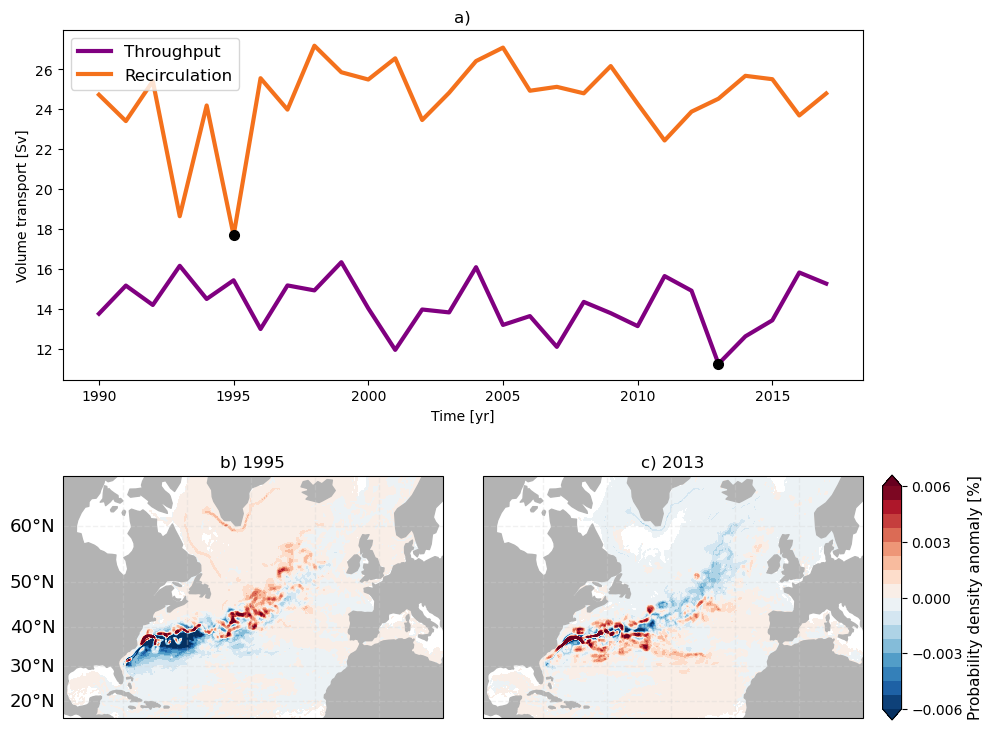

In [5]:
# Plotting Fig. 3
from cartopy import crs
import cartopy.feature as cfeatures
import matplotlib.gridspec as gridspec

data_proj = crs.PlateCarree( ) 
display_proj = crs.Mercator( )

fig = plt.figure(figsize=(10, 14))
gs = gridspec.GridSpec(2, 2, hspace=0.5, wspace=0.4)# height_ratios=[1, 1], hspace=0.3, wspace=0.3)

# a) Quantification
ax_time = fig.add_subplot(gs[0, :])
plt.plot(yrs,VTanSPG,linewidth=3,color='Purple',label='Throughput')
plt.plot(yrs,VTanSTG,linewidth=3,color=col1,label='Recirculation')
#
plt.plot(yrs[5],VTanSTG[5],'o',markersize=7,color='k')
plt.plot(yrs[23],VTanSPG[23],'o',markersize=7,color='k')
#
plt.xlabel('Time [yr]')
plt.ylabel('Volume transport [Sv]')
plt.legend(fontsize=12,loc='upper left')
ax_time.set_title('a)')

# b) Prob. dens map 1995
ax_map95 = fig.add_subplot(gs[1, 0], projection = display_proj)
ax_map95.set_extent([-99,20,15,67],crs=data_proj)
ax_map95.add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3),color=(.7, .7, .7),zorder=2)
g1=ax_map95.gridlines( draw_labels = True, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--') 
g1.ylabels_right = False
g1.xlabels_top = False
g1.xlabels_bottom = False
#
COUNTSn = 100*(COUNTSnanVT[:,:,5] / np.nansum(COUNTSnanVT[:,:,2])) #divide by total number of recorded particle counts for all bins
COUNTSanom = COUNTSn - COUNTSmeanVT
ctrs = ax_map95.contourf(X, Y, COUNTSanom.T, transform=data_proj, cmap='RdBu_r', levels=np.linspace(-0.006, 0.006, 17), extend='both')
#
ax_map95.set_title('b) 1995')

# c) Prob. den map 2013
ax_map13 = fig.add_subplot(gs[1, 1], projection = display_proj) 
ax_map13.set_extent([-99,20,15,67],crs=data_proj)
ax_map13.add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3),color=(.7, .7, .7),zorder=2)
g2=ax_map13.gridlines( draw_labels = False, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
#
COUNTSn = 100*(COUNTSnanVT[:,:,23] / np.nansum(COUNTSnanVT[:,:,20])) #divide by total number of recorded particle counts for all bins
COUNTSanom = COUNTSn - COUNTSmeanVT
ctrs = ax_map13.contourf(X, Y, COUNTSanom.T, transform=data_proj, cmap='RdBu_r', levels=np.linspace(-0.006, 0.006, 17), extend='both')
#
ax_map13.set_title('c) 2013')

ax_time.set_position([0.125, 0.5, 0.8, 0.25])
ax_map95.set_position([0.125,0.215, 0.38, 0.26]) # 
ax_map13.set_position([0.545,  0.215, 0.38, 0.26]) 

#cbar
cbar_ax = fig.add_axes([0.945, 0.257, 0.019, 0.175])  # [left, bottom, width, height]
cbar = fig.colorbar(ctrs, cax=cbar_ax, orientation='vertical', ticks=[-0.006,-0.003,0,0.003,0.006])
cbar.set_label('Probability density anomaly [%]',fontsize=11)

plt.rcParams.update({'font.size': 13})
